In [1]:
import os
import pickle
import warnings

import torch
import torchvision.transforms as transforms
from torchvision.io import read_image

warnings.filterwarnings('ignore')

In [2]:
nerv_save_dir = '../plotting_source_data/supplementary/NeRV/C-INRs_perhaps_care_about_objects'
mlp_save_dir = '../plotting_source_data/supplementary/MLP/C-INRs_perhaps_care_about_objects'

nerv_per_vid_patch_deltas_var_dict = pickle.load(open(f'{nerv_save_dir}/per_vid_patch_deltas_var_dict.pkl', 'rb'))
mlp_per_vid_patch_deltas_var_dict = pickle.load(open(f'{mlp_save_dir}/per_vid_patch_deltas_var_dict.pkl', 'rb'))

In [3]:
def get_first_rgb_img_frame(vidname, dataset_name):
    if dataset_name == "cityscapes":
        # the frame for training cityscapes is the first frame with provided mask/annotation
        cityscapes_vps_root = "../../data/cityscapes_vps"
        split = "val"
        panoptic_video_mask_dir = os.path.join(cityscapes_vps_root, split, "panoptic_video")
        
        data_path = os.path.join(cityscapes_vps_root, split, "img_all")
        
        rgb_mask_names = [file for file in sorted(os.listdir(panoptic_video_mask_dir)) if file.startswith(vidname)]
        # pick equally spaced frames, getting num_samples in total        

        # get RGB image corresponding to first mask above
        img_paths = [os.path.join(data_path, "_".join(rgb_mask_name.split("_")[2:5]) + "_leftImg8bit.png") for rgb_mask_name in rgb_mask_names]
        return img_paths[0]
    
    elif dataset_name == "vipseg":
        # all vipseg frames are annotated, we will take the first frame
        
        VIPSeg_720P_root = '../../data/VIPSeg-Dataset/VIPSeg/VIPSeg_720P'
        
        vid_path = os.path.join(VIPSeg_720P_root, "images", vidname)
        # pick equally spaced frames, getting num_samples in total
        img_paths = [os.path.join(vid_path, frame) for frame in sorted(os.listdir(vid_path))]
        
        return img_paths[0]

cityscapes_vids = ["0015", "0035", "0065", "0155", "0315", "0495"]
vipseg_vids = ["0_wHveSGjXyDY", "20_o-wWIdQ1H98", "79_brZzLyzaXbA", "127_-hIVCYO4C90", 
                "459_S0bHM1Hm0PU", "604_gFFyhdGeQ1A", "1327_e96s6pJ5x3Y", "1466_X9tU8ybzcFs",
                "1890_FIxEdRs9254", "2350_sCLtK1a2GGc"]

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def per_video_plot_box_and_whiskers(axs, nerv_patch_deltas_var_dict, mlp_patch_deltas_var_dict, colors):

    # Define dictionaries and keys
    dicts = [mlp_patch_deltas_var_dict, mlp_patch_deltas_var_dict, mlp_patch_deltas_var_dict, nerv_patch_deltas_var_dict, nerv_patch_deltas_var_dict, ]
    keys = ["layer_3", "layer_2", "layer_1", "head", "blk_3", ]

    for i, (key, data_dict) in enumerate(zip(keys, dicts)):
        sorted_deltas_dict = data_dict["sorted_deltas_dict"]
        tensor_dict = sorted_deltas_dict[key]
        
        instances_deltas = tensor_dict["instances_deltas"][~torch.isnan(tensor_dict["instances_deltas"])]
        rgb_clusters_deltas = tensor_dict["rgb_clusters_deltas"][~torch.isnan(tensor_dict["rgb_clusters_deltas"])]
        gabor_clusters_deltas = tensor_dict["gabor_clusters_deltas"][~torch.isnan(tensor_dict["gabor_clusters_deltas"])]
        gridcells_deltas = tensor_dict["gridcells_deltas"][~torch.isnan(tensor_dict["gridcells_deltas"])]
        
        tensor_logs = [np.log(np.sqrt(instances_deltas)),
                       np.log(np.sqrt(rgb_clusters_deltas)),
                       np.log(np.sqrt(gabor_clusters_deltas)),
                       np.log(np.sqrt(gridcells_deltas))]

        # Plot box plots for each tensor in the current layer
        box = axs[i].boxplot(
            tensor_logs, positions=[1, 2, 3, 4], patch_artist=True, 
            medianprops=dict(color="black", alpha=0.7),
            flierprops=dict(markeredgecolor='black', marker='o', markersize=4, linestyle='none', alpha=0.4))

        # Customize box colors
        for box_part, color in zip(box['boxes'], colors):
            box_part.set_facecolor(color)

        # turn off x and y ticks
        axs[i].set_xticks([]) # axs[i].set_xticks([1, 2, 3, 4])
        axs[i].set_yticks([])
        axs[i].set_xticklabels([])
        axs[i].set_yticklabels([])

    # Add legend
    # Add legend for different colors
    legend_labels = ['Instances', 'RGB Clusters', 'Gabor Clusters', 'Gridcells']
    legend_handles = [plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=color, markersize=10) for color in colors]

    return axs, (legend_labels, legend_handles)


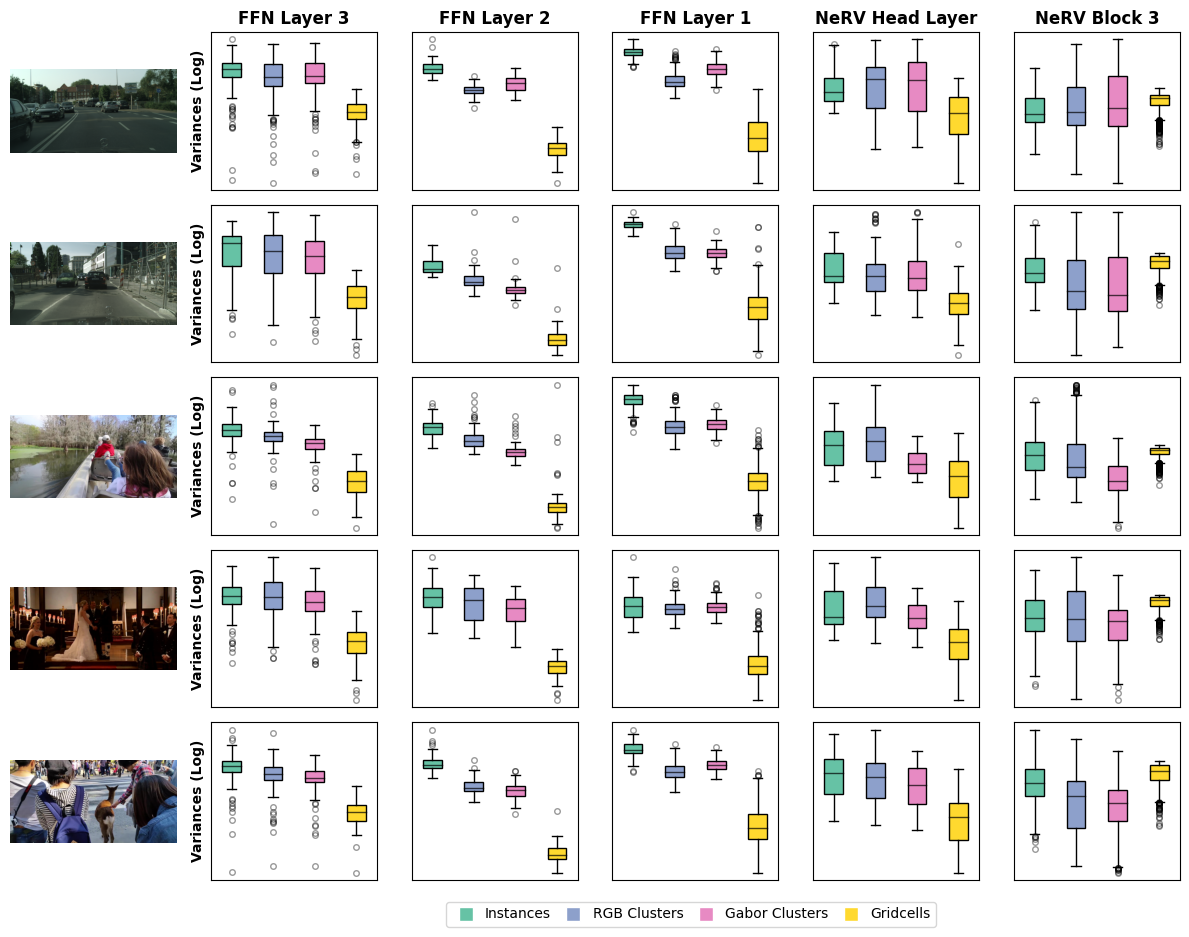

In [12]:
vidnames = nerv_per_vid_patch_deltas_var_dict.keys()
colors = plt.cm.get_cmap('Set2').colors
colors = [colors[i] for i in [0,2,3,5]]

# num_vids x 6
fig, axs = plt.subplots(len(vidnames), 6, figsize=(12, 9), tight_layout=True)#, gridspec_kw={'wspace': 0.7}) #  gridspec_kw={'width_ratios': [1, 1, 1, 1, 1, 1]},

for vid_idx, vidname in enumerate(vidnames):
    if vidname in cityscapes_vids:
        dataset_name = "cityscapes"
    elif vidname in vipseg_vids:
        dataset_name = "vipseg"
    rgb_img = read_image(get_first_rgb_img_frame(vidname, dataset_name))
    
    if vidname in vipseg_vids:
        rgb_img = transforms.CenterCrop((640, 1280))(rgb_img)
    
    axs[vid_idx][0].imshow(rgb_img.permute(1, 2, 0).numpy())
    axs[vid_idx][0].axis('off')
    
    box_plot_axes = [axs[vid_idx][1], axs[vid_idx][2], axs[vid_idx][3], axs[vid_idx][4], axs[vid_idx][5]]
    
    populated_axs, (legend_labels, legend_handles) =\
        per_video_plot_box_and_whiskers(box_plot_axes, nerv_per_vid_patch_deltas_var_dict[vidname], mlp_per_vid_patch_deltas_var_dict[vidname], colors)
        
    axs[vid_idx][1], axs[vid_idx][2], axs[vid_idx][3], axs[vid_idx][4], axs[vid_idx][5] = populated_axs

for i in range(len(vidnames)):
    axs[i][1].set_ylabel('Variances (Log)', fontsize=10, fontweight='bold') # Deviation from Actual Contribution (Log)

axs[0][1].set_title('FFN Layer 3', fontsize=12, fontweight='bold')
axs[0][2].set_title('FFN Layer 2', fontsize=12, fontweight='bold')
axs[0][3].set_title('FFN Layer 1', fontsize=12, fontweight='bold')
axs[0][4].set_title('NeRV Head Layer', fontsize=12, fontweight='bold')
axs[0][5].set_title('NeRV Block 3', fontsize=12, fontweight='bold')

# reduce whitespace between columns
# fig.subplots_adjust(wspace=-1.0, hspace=0.01)
plt.subplots_adjust(wspace=0.2)

fig.legend(legend_handles, legend_labels, loc='upper center', ncol=4, bbox_to_anchor=(0.58, 0), columnspacing=0.6, handletextpad=0.4)


In [13]:
os.makedirs('../outputs/supplementary/', exist_ok=True)
fig.savefig('../outputs/supplementary/variance_of_patch_deltas.pdf', bbox_inches="tight", pad_inches=0.02)